In [33]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm

### Configuration

In [36]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cinic_mean_RGB = [0.47889522, 0.47227842, 0.43047404]
cinic_std_RGB  = [0.24205776, 0.23828046, 0.25874835]

N_STEPS = 50

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

CFG = {
    
    # Path to weights
    "weights_path": "./mobilenet/experiments/augmentation_first_part/experiments/mbv2_flip_seed_42/best.pth",

    # Path to analyzed image
    "image_path": None,

    # Option 2 -> choose by index or randomly
    "image_dir": "./input/test",   # np. folder test/train/valid
    "image_index": 0,
    "random_pick": False,
    "seed": 42,

    # Target to explain
    # "pred"  -> class predicted by model
    # "label" -> true label class
    # "class" -> manually selected class
    "target_mode": "pred",
    "target_class": 3,   # used only when target_mode = "class"

    # Integrated Gradients settings
    "n_steps": 50,
    "internal_batch_size": 10,

    # Comaprison with Grad-CAM
    # "positive" -> positive impact to target [0,1]
    # "abs"      -> impact absolute value [0,1]
    # "signed01" -> impact with sign scaled to [0,1]
    "compare_mode": "positive",

    # Visualization parameters
    "overlay_alpha": 0.50,
    "figsize": (14, 4.5),
    "display_interpolation": "bicubic",
}

IMG_EXTS = {".png"}

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cinic_mean_RGB, cinic_std_RGB)
])

### Image choice

In [37]:
def list_images(image_dir):
    image_dir = Path(image_dir)
    files = [p for p in image_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    files = sorted(files)
    if not files:
        raise FileNotFoundError(f"Images not found in: {image_dir}")
    return files

In [38]:
def print_image_menu(image_dir, limit=30):
    files = list_images(image_dir)
    print(f"Image number: {len(files)}")
    for i, p in enumerate(files[:limit]):
        print(f"[{i:03d}] {p}")
    if len(files) > limit:
        print(f"... and {len(files) - limit} more")
    return files

In [39]:
def choose_image(image_path=None, image_dir=None, image_index=0, random_pick=False, seed=42):
    if image_path is not None:
        chosen_path = Path(image_path)
        if not chosen_path.exists():
            raise FileNotFoundError(chosen_path)
    else:
        files = list_images(image_dir)
        if random_pick:
            rng = random.Random(seed)
            idx = rng.randrange(len(files))
        else:
            idx = image_index

        if idx < 0 or idx >= len(files):
            raise IndexError(f"image_index={idx}, liczba obrazów={len(files)}")

        chosen_path = files[idx]

    label_name = chosen_path.parent.name if chosen_path.parent.name in CLASS_NAMES else None
    return chosen_path, label_name

### Image load

In [44]:
def load_image_tensor(image_path):
    pil_img = Image.open(image_path).convert("RGB")
    x = base_transform(pil_img).unsqueeze(0).to(DEVICE)   # [1,3,H,W]
    return pil_img, x

In [45]:
def denormalize_tensor(x):
    if x.dim() == 3:
        x = x.unsqueeze(0)

    mean_t = torch.tensor(cinic_mean_RGB, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    std_t = torch.tensor(cinic_std_RGB, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)

    img = (x * std_t + mean_t).clamp(0, 1)
    return img[0].permute(1, 2, 0).detach().cpu().numpy()

In [41]:
def choose_image(image_path=None, image_dir=None, image_index=0, random_pick=False, seed=42):
    if image_path is not None:
        chosen_path = Path(image_path)
        if not chosen_path.exists():
            raise FileNotFoundError(chosen_path)
    else:
        files = list_images(image_dir)
        if random_pick:
            rng = random.Random(seed)
            idx = rng.randrange(len(files))
        else:
            idx = image_index

        if idx < 0 or idx >= len(files):
            raise IndexError(f"image_index={idx}, liczba obrazów={len(files)}")

        chosen_path = files[idx]

    label_name = chosen_path.parent.name if chosen_path.parent.name in CLASS_NAMES else None
    return chosen_path, label_name

### Building loaders

In [14]:
def build_cinic10_loaders(root, batch_size=128, num_workers=4):
    train_set = datasets.ImageFolder(
        os.path.join(root, "train"),
        transform=base_transform
    )
    valid_set = datasets.ImageFolder(
        os.path.join(root, "valid"),
        transform=base_transform
    )
    test_set = datasets.ImageFolder(
        os.path.join(root, "test"),
        transform=base_transform
    )

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    valid_loader = DataLoader(
        valid_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, valid_loader, test_loader

### Obtaining mobilenet model

In [21]:
def get_mobilenetv2(num_classes, dropout_rate = 0):
    m = models.mobilenet_v2()
    old_conv = m.features[0][0]
    m.features[0][0] = nn.Conv2d(
        in_channels=old_conv.in_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=1,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None)
    )
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(m.classifier[1].in_features, num_classes)
    )
    return m

### Loading trained model

In [23]:
def load_trained_model(model, weights_path):
    state = torch.load(weights_path, map_location=DEVICE)
    model.load_state_dict(state["model"])
    model.to(DEVICE)
    model.eval()
    return model

### Resolving target

In [51]:
@torch.no_grad()
def predict_top_class(model, x):
    model.eval()
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    pred_class = probs.argmax(dim=1)
    pred_conf = probs.gather(1, pred_class.unsqueeze(1)).squeeze(1)
    return pred_class, pred_conf

In [43]:
def resolve_target(pred_class, label_name, target_mode="pred", target_class=None):
    if target_mode == "pred":
        return pred_class, f"pred: {CLASS_NAMES[pred_class]}"

    if target_mode == "label":
        if label_name is None:
            raise ValueError("Unable to read the label from the folder name.")
        cls = CLASS_NAMES.index(label_name)
        return cls, f"label: {label_name}"

    if target_mode == "class":
        if target_class is None:
            raise ValueError("Set 'target_class' configuration parameter")
        cls = int(target_class)
        return cls, f"class: {CLASS_NAMES[cls]}"

    raise ValueError(f"Unknown resolving target class: {target_mode}")

### Creating black baseline

In [8]:
def make_black_baseline_normalized(x, mean, std):
    mean_t = torch.tensor(mean, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    baseline = (0.0 - mean_t) / std_t
    return baseline.expand_as(x)

### [0,1] map normalization

In [ ]:
def normalize_0_1(x, eps=1e-8):
    """
    x: [H, W] albo [B, H, W]
    """
    if x.dim() == 2:
        return (x - x.min()) / (x.max() - x.min() + eps)

    if x.dim() == 3:
        flat = x.view(x.size(0), -1)
        mins = flat.min(dim=1)[0].view(-1, 1, 1)
        maxs = flat.max(dim=1)[0].view(-1, 1, 1)
        return (x - mins) / (x.max(dim=1, keepdim=True)[0] * 0 + maxs - mins + eps)

    raise ValueError(f"Unsupported shape: {x.shape}")

In [9]:
def normalize_0_1_batch(x, eps=1e-8):
    """
    x: [B, H, W]
    """
    flat = x.view(x.size(0), -1)
    mins = flat.min(dim=1)[0].view(-1, 1, 1)
    maxs = flat.max(dim=1)[0].view(-1, 1, 1)
    return (x - mins) / (maxs - mins + eps)

### Core function IG

In [52]:
def integrated_gradients_cinic10(
    model,
    x,
    target=None,
    n_steps=50,
    internal_batch_size=10,
):
    """
    x: [B, 3, 32, 32] - już po Normalize(mean, std)
    target:
      - None: wyjaśnia klasę przewidzianą przez model
      - int: ta sama klasa dla całego batcha
      - tensor/list [B]: osobny target dla każdego obrazu

    Zwraca:
      attributions: [B, 3, H, W]
      heatmap_raw:  [B, H, W]
      heatmap_norm: [B, H, W]
      target:       [B]
      delta
    """
    model.eval()
    x = x.to(DEVICE)

    if not x.requires_grad:
        x = x.detach().clone().requires_grad_(True)

    if target is None:
        target, _ = predict_top_class(model, x)
    elif isinstance(target, int):
        target = torch.full((x.size(0),), target, dtype=torch.long, device=x.device)
    elif isinstance(target, list):
        target = torch.tensor(target, dtype=torch.long, device=x.device)
    else:
        target = target.to(x.device)

    baseline = make_black_baseline_normalized(
        x,
        mean=cinic_mean_RGB,
        std=cinic_std_RGB
    )

    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        inputs=x,
        baselines=baseline,
        target=target,
        n_steps=n_steps,
        method="gausslegendre",
        internal_batch_size=internal_batch_size,
        return_convergence_delta=True,
    )

    # mapa 2D przez średnią po RGB
    heatmap_raw = attributions.mean(dim=1)   # [B, H, W]

    # normalizacja do [0,1]
    heatmap_norm = normalize_0_1_batch(heatmap_raw)

    return {
        "attributions": attributions.detach(),
        "heatmap_raw": heatmap_raw.detach(),
        "heatmap_norm": heatmap_norm.detach(),
        "target": target.detach(),
        "delta": delta.detach() if torch.is_tensor(delta) else delta,
    }

### Single image

In [15]:
def integrated_gradients_single_image(model, x_single, target=None):
    """
    x_single: [3, 32, 32] albo [1, 3, 32, 32]
    """
    if x_single.dim() == 3:
        x_single = x_single.unsqueeze(0)

    result = integrated_gradients_cinic10(
        model=model,
        x=x_single,
        target=target,
        n_steps=50,
        internal_batch_size=10,
    )

    return {
        "attributions": result["attributions"][0],   # [3, H, W]
        "heatmap_raw": result["heatmap_raw"][0],     # [H, W]
        "heatmap_norm": result["heatmap_norm"][0],   # [H, W]
        "target": int(result["target"][0].item()),
        "delta": float(result["delta"][0].item()) if torch.is_tensor(result["delta"]) else result["delta"],
    }

### Image denormalization

In [25]:
def denormalize_image(x, mean, std):
    """
    x: [3, H, W] albo [1, 3, H, W]
    """
    if x.dim() == 3:
        x = x.unsqueeze(0)

    mean_t = torch.tensor(mean, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)

    img = (x * std_t + mean_t).clamp(0, 1)
    return img[0].permute(1, 2, 0).detach().cpu().numpy()

### Visualizations

In [64]:
def minmax_0_1(x, eps=1e-8):
    x_min = x.min()
    x_max = x.max()
    return (x - x_min) / (x_max - x_min + eps)


def build_maps(attributions, compare_mode="positive", clip_percentile=99.0, eps=1e-8):
    """
    attributions: [1, 3, H, W]

    Zwraca:
      signed_map   [H, W]  -> do signed heatmapy
      compare_map  [H, W]  -> do overlay [0,1]
      compare_label
    """
    # mean for RGB channels
    signed_map = attributions[0].mean(dim=0)   # [H, W]

    # clipping for visualization
    abs_vals = signed_map.abs().flatten()
    vmax_signed = torch.quantile(abs_vals, clip_percentile / 100.0)
    vmax_signed = torch.clamp(vmax_signed, min=eps)

    signed_map = torch.clamp(signed_map, min=-vmax_signed, max=vmax_signed)
    signed_map = signed_map / vmax_signed   # teraz skala ~ [-1, 1]

    # comparison maps
    positive_map = signed_map.clamp(min=0)
    abs_map = attributions[0].abs().mean(dim=0)

    if compare_mode == "positive":
        vmax_cmp = torch.quantile(positive_map.flatten(), clip_percentile / 100.0)
        vmax_cmp = torch.clamp(vmax_cmp, min=eps)
        compare_map = torch.clamp(positive_map / vmax_cmp, 0, 1)
        compare_label = "Positive attribution [0,1]"

    elif compare_mode == "abs":
        vmax_cmp = torch.quantile(abs_map.flatten(), clip_percentile / 100.0)
        vmax_cmp = torch.clamp(vmax_cmp, min=eps)
        compare_map = torch.clamp(abs_map / vmax_cmp, 0, 1)
        compare_label = "Absolute attribution [0,1]"

    elif compare_mode == "signed01":
        compare_map = (signed_map + 1.0) / 2.0
        compare_label = "Signed attribution mapped to [0,1]"

    else:
        raise ValueError(f"Unknown compare_mode: {compare_mode}")

    return signed_map, compare_map, compare_label

In [70]:
import matplotlib.pyplot as plt
import numpy as np

def plot_explanation(
    x,
    signed_map,
    compare_map,
    compare_label,
    pred_class,
    pred_conf,
    target_class,
    target_desc,
    overlay_alpha=0.45,
    figsize=(15, 5),
    interpolation="bilinear",
):
    img_np = denormalize_tensor(x)
    signed_np = signed_map.detach().cpu().numpy()
    compare_np = compare_map.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1) Input
    axes[0].imshow(img_np, interpolation="nearest")
    axes[0].set_title(
        f"Input\npred={CLASS_NAMES[pred_class]} ({pred_conf:.3f})\nexplained={CLASS_NAMES[target_class]}",
        fontsize=11,
        fontweight="bold"
    )
    axes[0].axis("off")

    # 2) Signed IG
    im1 = axes[1].imshow(
        signed_np,
        cmap="RdBu_r",      # bardziej raportowe niż seismic
        vmin=-1,
        vmax=1,
        interpolation=interpolation,
    )
    axes[1].set_title(
        "Signed IG\nblue = negative, red = positive",
        fontsize=11,
        fontweight="bold"
    )
    axes[1].axis("off")
    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Normalized attribution [-1, 1]", fontsize=10)
    cbar1.set_ticks([-1, -0.5, 0, 0.5, 1])

    # 3) Overlay
    axes[2].imshow(img_np, interpolation="nearest")
    im2 = axes[2].imshow(
        compare_np,
        cmap="inferno",     # żywe, ale mniej agresywne niż turbo
        alpha=overlay_alpha,
        interpolation=interpolation,
        vmin=0.0,
        vmax=1.0,
    )
    axes[2].set_title(
        f"Overlay\n{compare_label}",
        fontsize=11,
        fontweight="bold"
    )
    axes[2].axis("off")
    cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    cbar2.set_label(compare_label, fontsize=10)
    cbar2.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

    fig.suptitle(
        f"Integrated Gradients | target = {target_desc}",
        y=1.02,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

### Transformation for plotting

In [68]:
def to_python_scalar(x):
    if torch.is_tensor(x):
        if x.numel() == 1:
            return x.item()
        raise ValueError(f"Tensor has more than one attribute: shape={tuple(x.shape)}")
    return x

### Evaluating

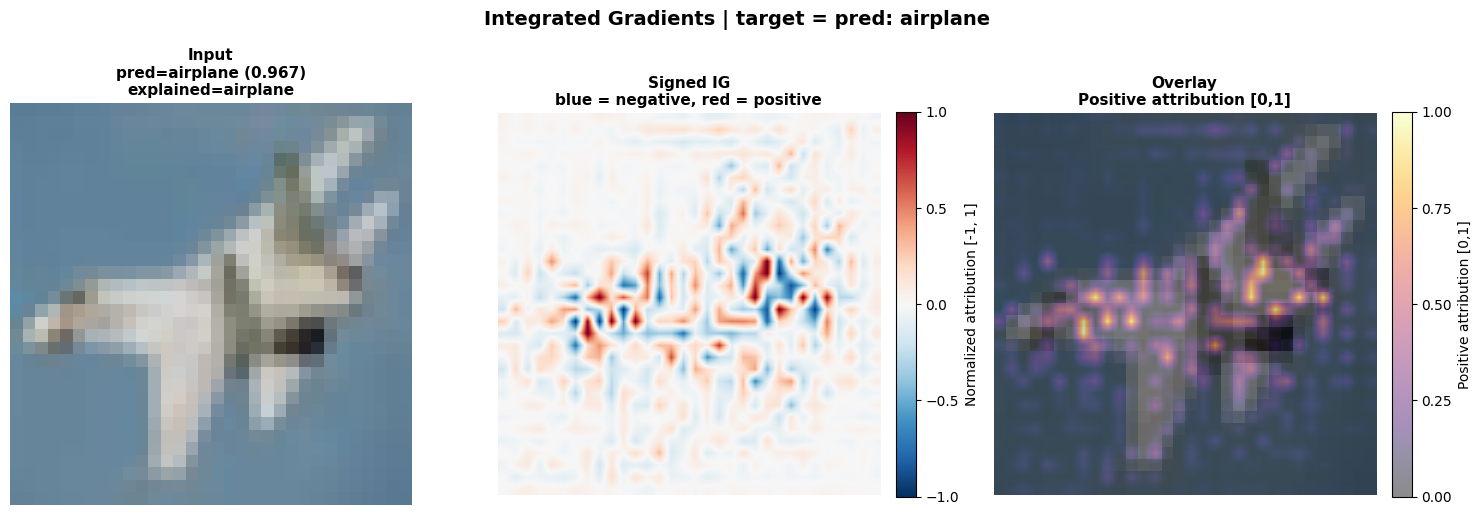

Image path      : input\test\airplane\cifar10-test-10.png
Folder label    : airplane
Predicted class : 0 (airplane)
Pred confidence : 0.9673
Explained target: 0 (airplane)
Delta           : -0.3627023696899414


In [71]:
CFG["compare_mode"] = "positive"
CFG["overlay_alpha"] = 0.45
CFG["figsize"] = (15, 5)
CFG["display_interpolation"] = "bilinear"

chosen_path, label_name = choose_image(
        image_path=CFG["image_path"],
        image_dir=CFG["image_dir"],
        image_index=CFG["image_index"],
        random_pick=CFG["random_pick"],
        seed=CFG["seed"],
    )

model = get_mobilenetv2(10)
model = load_trained_model(model=model, weights_path=CFG["weights_path"])

pil_img, x = load_image_tensor(chosen_path)

pred_class, pred_conf = predict_top_class(model, x)

target_class, target_desc = resolve_target(
    pred_class=pred_class,
    label_name=label_name,
    target_mode=CFG["target_mode"],
    target_class=CFG["target_class"],
)

result = integrated_gradients_cinic10(
    model=model,
    x=x,
    target=target_class,
    n_steps=CFG["n_steps"],
    internal_batch_size=CFG["internal_batch_size"],
)

attributions = result["attributions"]
delta = result["delta"]

signed_map, compare_map, compare_label = build_maps(
    attributions=attributions,
    compare_mode=CFG["compare_mode"],
)


pred_class = to_python_scalar(pred_class)
pred_conf = to_python_scalar(pred_conf)
target_class = to_python_scalar(target_class)
delta_print = to_python_scalar(delta) if torch.is_tensor(delta) and delta.numel() == 1 else delta

plot_explanation(
    x=x,
    signed_map=signed_map,
    compare_map=compare_map,
    compare_label=compare_label,
    pred_class=pred_class,
    pred_conf=pred_conf,
    target_class=target_class,
    target_desc=target_desc,
    overlay_alpha=CFG["overlay_alpha"],
    figsize=CFG["figsize"],
    interpolation=CFG["display_interpolation"],
)

print(f"Image path      : {chosen_path}")
print(f"Folder label    : {label_name}")
print(f"Predicted class : {pred_class} ({CLASS_NAMES[pred_class]})")
print(f"Pred confidence : {pred_conf:.4f}")
print(f"Explained target: {target_class} ({CLASS_NAMES[target_class]})")
print(f"Delta           : {delta_print}")

### Second version

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def plot_explanation(
    x,
    signed_map,
    compare_map,
    compare_label,
    pred_class,
    pred_conf,
    target_class,
    target_desc,
    overlay_alpha=0.62,
    figsize=(15, 5),
    interpolation="bilinear",
):
    img_np = denormalize_tensor(x)
    signed_np = signed_map.detach().cpu().numpy()
    compare_np = compare_map.detach().cpu().numpy()

    compare_np = np.clip(compare_np, 0, 1) ** 0.75

    threshold = 0.15
    compare_masked = np.ma.masked_where(compare_np < threshold, compare_np)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1) Input
    axes[0].imshow(img_np, interpolation="nearest")
    axes[0].set_title(
        f"Input\npred={CLASS_NAMES[pred_class]} ({pred_conf:.3f})\nexplained={CLASS_NAMES[target_class]}",
        fontsize=11,
        fontweight="bold"
    )
    axes[0].axis("off")

    # 2) Signed heatmap
    im1 = axes[1].imshow(
        signed_np,
        cmap="seismic",
        vmin=-1,
        vmax=1,
        interpolation=interpolation,
    )
    axes[1].set_title(
        "Signed IG\nblue = negative, red = positive",
        fontsize=11,
        fontweight="bold"
    )
    axes[1].axis("off")
    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Normalized attribution [-1, 1]", fontsize=10)
    cbar1.set_ticks([-1, -0.5, 0, 0.5, 1])

    # 3) Overlay
    axes[2].imshow(img_np, interpolation="nearest")
    im2 = axes[2].imshow(
        compare_masked,
        cmap="plasma",  
        alpha=overlay_alpha,
        interpolation=interpolation,
        vmin=threshold,
        vmax=1.0,
    )
    axes[2].set_title(
        f"Overlay\n{compare_label}",
        fontsize=11,
        fontweight="bold"
    )
    axes[2].axis("off")
    cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    cbar2.set_label(compare_label, fontsize=10)
    cbar2.set_ticks([0.2, 0.4, 0.6, 0.8, 1.0])

    fig.suptitle(
        f"Integrated Gradients | target = {target_desc}",
        y=1.02,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

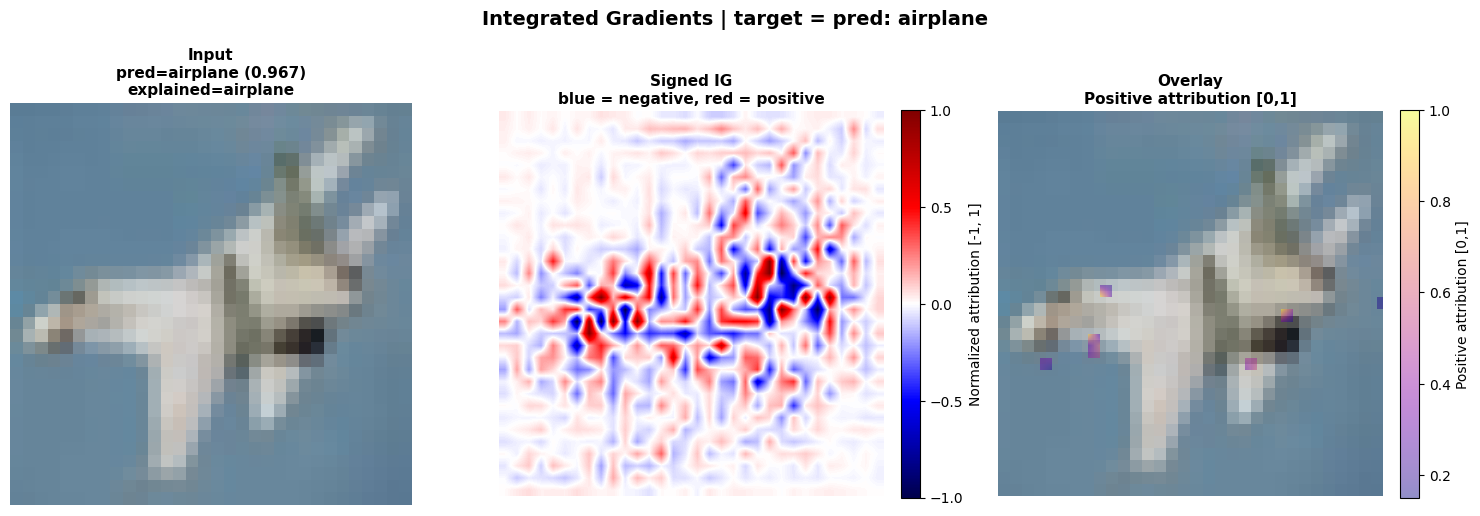

Image path      : input\test\airplane\cifar10-test-10.png
Folder label    : airplane
Predicted class : 0 (airplane)
Pred confidence : 0.9673
Explained target: 0 (airplane)
Delta           : -0.3627023696899414


In [74]:
CFG["compare_mode"] = "positive"
CFG["overlay_alpha"] = 0.45
CFG["figsize"] = (15, 5)
CFG["display_interpolation"] = "bilinear"

chosen_path, label_name = choose_image(
        image_path=CFG["image_path"],
        image_dir=CFG["image_dir"],
        image_index=CFG["image_index"],
        random_pick=CFG["random_pick"],
        seed=CFG["seed"],
    )

model = get_mobilenetv2(10)
model = load_trained_model(model=model, weights_path=CFG["weights_path"])

pil_img, x = load_image_tensor(chosen_path)

pred_class, pred_conf = predict_top_class(model, x)

target_class, target_desc = resolve_target(
    pred_class=pred_class,
    label_name=label_name,
    target_mode=CFG["target_mode"],
    target_class=CFG["target_class"],
)

result = integrated_gradients_cinic10(
    model=model,
    x=x,
    target=target_class,
    n_steps=CFG["n_steps"],
    internal_batch_size=CFG["internal_batch_size"],
)

attributions = result["attributions"]
delta = result["delta"]

signed_map, compare_map, compare_label = build_maps(
    attributions=attributions,
    compare_mode=CFG["compare_mode"],
)


pred_class = to_python_scalar(pred_class)
pred_conf = to_python_scalar(pred_conf)
target_class = to_python_scalar(target_class)
delta_print = to_python_scalar(delta) if torch.is_tensor(delta) and delta.numel() == 1 else delta

plot_explanation(
    x=x,
    signed_map=signed_map,
    compare_map=compare_map,
    compare_label=compare_label,
    pred_class=pred_class,
    pred_conf=pred_conf,
    target_class=target_class,
    target_desc=target_desc,
    overlay_alpha=CFG["overlay_alpha"],
    figsize=CFG["figsize"],
    interpolation=CFG["display_interpolation"],
)

print(f"Image path      : {chosen_path}")
print(f"Folder label    : {label_name}")
print(f"Predicted class : {pred_class} ({CLASS_NAMES[pred_class]})")
print(f"Pred confidence : {pred_conf:.4f}")
print(f"Explained target: {target_class} ({CLASS_NAMES[target_class]})")
print(f"Delta           : {delta_print}")